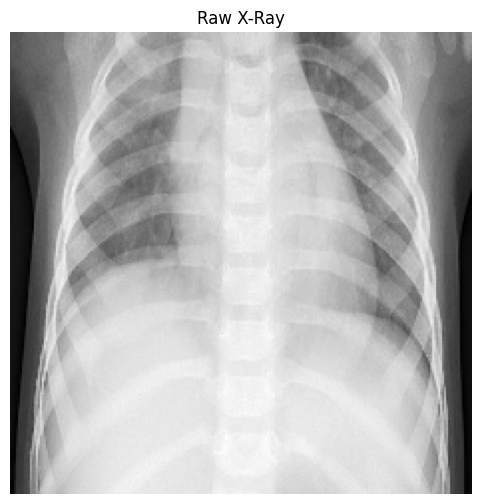

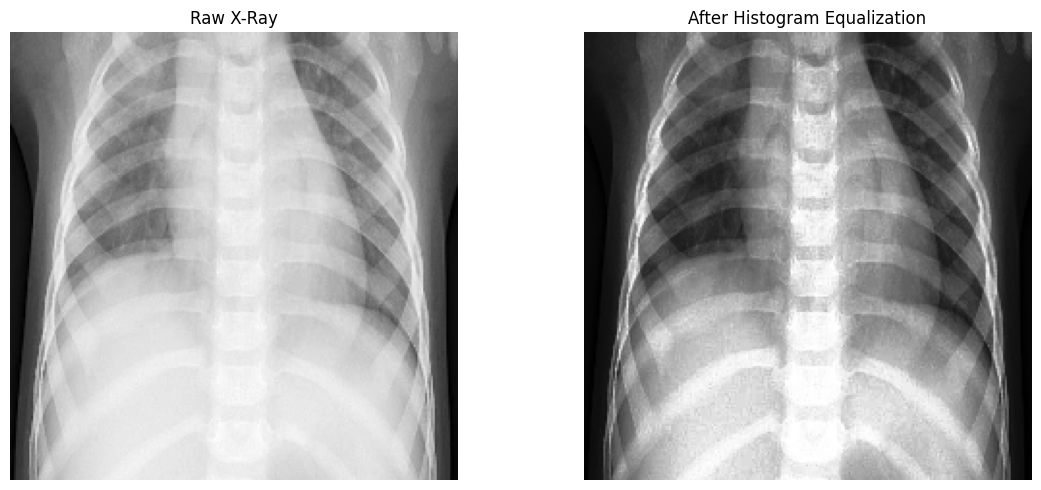

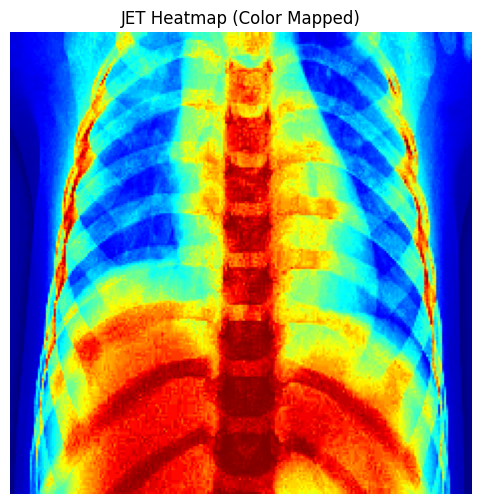

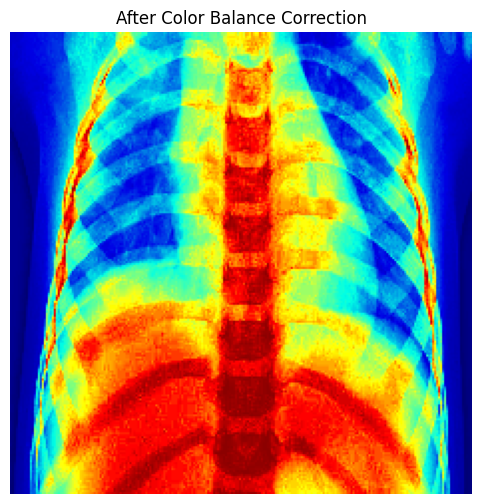

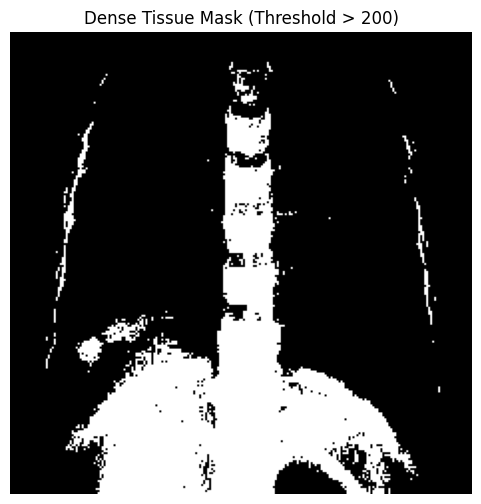

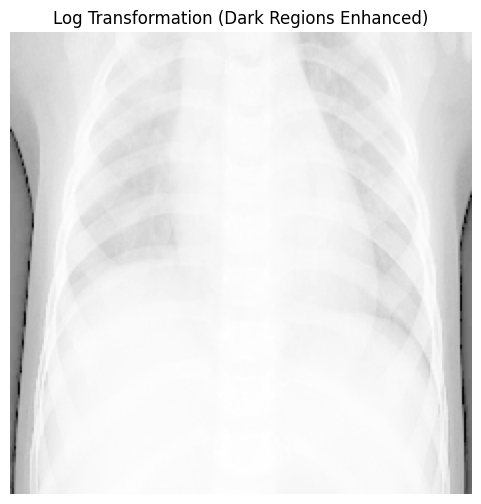

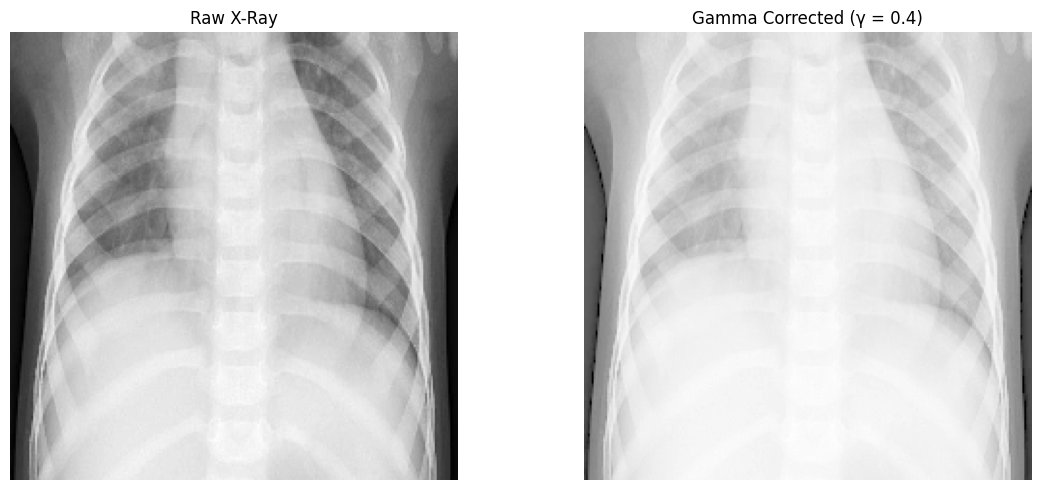

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# load xray in grayscale
xray = cv2.imread('xray.jpg', cv2.IMREAD_GRAYSCALE)

# 1 - display raw xray
plt.figure(figsize=(6, 6))
plt.imshow(xray, cmap='gray')
plt.title('Raw X-Ray')
plt.axis('off')
plt.show()

# 2 - histogram equalization
equalized = cv2.equalizeHist(xray)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(xray, cmap='gray')
axes[0].set_title('Raw X-Ray')
axes[0].axis('off')
axes[1].imshow(equalized, cmap='gray')
axes[1].set_title('After Histogram Equalization')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# 3 - false color heatmap
heatmap = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)
heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(heatmap_rgb)
plt.title('JET Heatmap (Color Mapped)')
plt.axis('off')
plt.show()

# 4 - color balance correction
balanced = heatmap_rgb.copy().astype(np.float32)
balanced[:, :, 0] *= 1.1   # slight red boost
balanced[:, :, 2] *= 0.9   # slight blue reduction
balanced = np.clip(balanced, 0, 255).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(balanced)
plt.title('After Color Balance Correction')
plt.axis('off')
plt.show()

# 5 - thresholding for dense tissue
_, dense_mask = cv2.threshold(equalized, 200, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(6, 6))
plt.imshow(dense_mask, cmap='gray')
plt.title('Dense Tissue Mask (Threshold > 200)')
plt.axis('off')
plt.show()

# 6 - log transformation on raw xray
c = 255 / np.log(1 + np.max(xray))
log_transformed = c * np.log(1 + xray.astype(np.float64))
log_transformed = np.uint8(log_transformed)

plt.figure(figsize=(6, 6))
plt.imshow(log_transformed, cmap='gray')
plt.title('Log Transformation (Dark Regions Enhanced)')
plt.axis('off')
plt.show()

# 7 - gamma correction (gamma < 1 brightens midtones)
gamma = 0.4
gamma_corrected = np.array(255 * (xray / 255.0) ** gamma, dtype=np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(xray, cmap='gray')
axes[0].set_title('Raw X-Ray')
axes[0].axis('off')
axes[1].imshow(gamma_corrected, cmap='gray')
axes[1].set_title(f'Gamma Corrected (γ = {gamma})')
axes[1].axis('off')
plt.tight_layout()
plt.show()